# Chest X-Ray Images (Pneumonia) Classification

In [2]:
import pandas as pd
import numpy as np
import os
import cv2
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

In [3]:
import warnings
warnings.filterwarnings("ignore")

## Exploraty Data Analysis and Data Preprocessing

In [4]:
labels=["NORMAL","PNEUMONIA"]
img_path="chest_xray/"

In [5]:
data = []

In [6]:
for split in ["train", "test", "val"]:
    for label in labels:
        folder_path = os.path.join(img_path, split, label)        
        if os.path.exists(folder_path):
            for file_name in os.listdir(folder_path):
                if file_name.endswith(('.jpeg', '.png', '.jpg')):
                    full_path = os.path.join(folder_path, file_name)
                    numeric_label = 0 if label == "NORMAL" else 1
                    data.append({"image_path": full_path, "label": numeric_label, "category": label})

In [7]:
df = pd.DataFrame(data)

In [8]:
df

,image_path,label,category
0,chest_xray/train\NORMAL\IM-0115-0001.jpeg,0,NORMAL
1,chest_xray/train\NORMAL\IM-0117-0001.jpeg,0,NORMAL
2,chest_xray/train\NORMAL\IM-0119-0001.jpeg,0,NORMAL
3,chest_xray/train\NORMAL\IM-0122-0001.jpeg,0,NORMAL
4,chest_xray/train\NORMAL\IM-0125-0001.jpeg,0,NORMAL
...,...,...,...
5851,chest_xray/val\PNEUMONIA\person1949_bacteria_4...,1,PNEUMONIA
5852,chest_xray/val\PNEUMONIA\person1950_bacteria_4...,1,PNEUMONIA
5853,chest_xray/val\PNEUMONIA\person1951_bacteria_4...,1,PNEUMONIA
5854,chest_xray/val\PNEUMONIA\person1952_bacteria_4...,1,PNEUMONIA


In [9]:
df.isnull().sum()

image_path    0
label         0
category      0
dtype: int64

In [10]:
x = []
for img_path in df["image_path"]:
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (128, 128))
    img = img / 255.0  
    x.append(img)

In [11]:
x = np.array(x, dtype=np.float32)
y = np.array(df["label"], dtype=np.int32)

# Model Training and Testing

In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20,random_state=42,stratify=y)

In [13]:
model = Sequential()
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ezberlemeyi (overfitting) önlemek için %50 nöron kapatma
    layers.Dense(1, activation='sigmoid') # İkili sınıflandırma (0: Normal, 1: Pneumonia)
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,batch_size=64,verbose=1)

Epoch 1/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 85s 1s/step - accuracy: 0.8518 - loss: 0.3520 - val_accuracy: 0.9352 - val_loss: 0.1742
Epoch 2/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9332 - loss: 0.1794 - val_accuracy: 0.9462 - val_loss: 0.1578
Epoch 3/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 79s 1s/step - accuracy: 0.9449 - loss: 0.1390 - val_accuracy: 0.9377 - val_loss: 0.1740
Epoch 4/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.9528 - loss: 0.1285 - val_accuracy: 0.9445 - val_loss: 0.1515
Epoch 5/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.9605 - loss: 0.1129 - val_accuracy: 0.9437 - val_loss: 0.1486
Epoch 6/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 136s 1s/step - accuracy: 0.9620 - loss: 0.1014 - val_accuracy: 0.9539 - val_loss: 0.1412
Epoch 7/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.9675 - loss: 0.0888 - val_accuracy: 0.9548 - val_loss: 0.1458
Epoch 8/10
74/74 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9684 - loss: 0.0823 - val_accuracy: 0.9539 - val_los

# Data Visualiztion

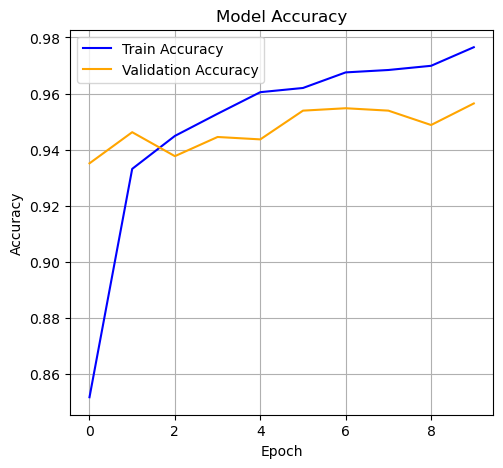

In [15]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

37/37 ━━━━━━━━━━━━━━━━━━━━ 6s 153ms/step


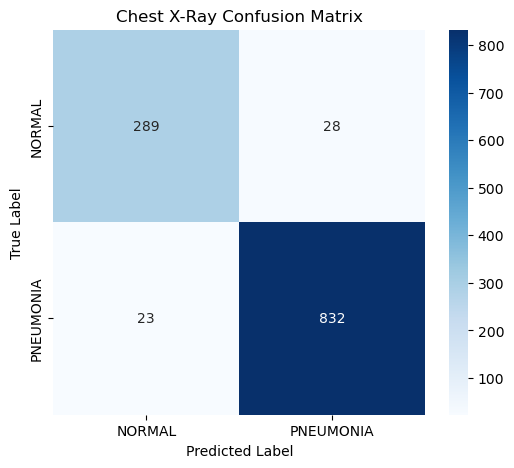

In [16]:
predictions = model.predict(x_test)
y_pred = (predictions > 0.5).astype(int)
class_names = ['NORMAL', 'PNEUMONIA']

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('Chest X-Ray Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [17]:
model.save("chest_xray_model.keras")

# Transfer Learning

In [23]:
dataset_dir = 'chest_xray/train'

In [24]:
img_shape = (128, 128)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_shape,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_shape,
    batch_size=batch_size
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.
Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


In [25]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [26]:
from tensorflow.keras.applications import MobileNetV2

img_shape = (128, 128, 3) 
base_model = MobileNetV2(
    weights='imagenet', 
    include_top=False, 
    input_shape=img_shape
)
base_model.trainable = False 

model_chest_tl = models.Sequential([
    layers.Rescaling(1./255, input_shape=img_shape),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),   
    layers.Dense(1, activation='sigmoid')  
])

model_chest_tl.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy', 
    metrics=['accuracy', tf.keras.metrics.Recall(name='recall')]  
)

model_chest_tl.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [27]:
history= model_chest_tl.fit(train_ds,validation_data=val_ds,epochs=5,verbose=1)

Epoch 1/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 82s 429ms/step - accuracy: 0.9257 - loss: 0.1861 - recall: 0.9533 - val_accuracy: 0.9626 - val_loss: 0.0907 - val_recall: 0.9667
Epoch 2/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 50s 385ms/step - accuracy: 0.9585 - loss: 0.1070 - recall: 0.9736 - val_accuracy: 0.9616 - val_loss: 0.0964 - val_recall: 0.9580
Epoch 3/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 99s 516ms/step - accuracy: 0.9653 - loss: 0.0936 - recall: 0.9742 - val_accuracy: 0.9597 - val_loss: 0.0935 - val_recall: 0.9938
Epoch 4/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 73s 445ms/step - accuracy: 0.9655 - loss: 0.0905 - recall: 0.9749 - val_accuracy: 0.9674 - val_loss: 0.0804 - val_recall: 0.9679
Epoch 5/5
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 501ms/step - accuracy: 0.9722 - loss: 0.0773 - recall: 0.9808 - val_accuracy: 0.9664 - val_loss: 0.0795 - val_recall: 0.9679
